# Stage 2 — Anomaly Detection (AI4I 2020)

Three detectors combined via score fusion:

 Detector | Type | Catches |

1. Z-score (global + dynamic) | Statistical, per-sensor | Point anomalies |
2. Isolation Forest | ML, multivariate | Contextual / combination anomalies |
3. Autoencoder (PyTorch) | Neural reconstruction | Unusual sensor combinations |

Primary dataset: AI4I 2020. Agri IoT deferred to Stage 2b if time permits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = Path('../data')
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Thresholds ────────────────────────────────────────────────────────────────
ZSCORE_THRESHOLD = 3.0
IF_CONTAMINATION = 0.034   # matches known AI4I failure rate
AE_PERCENTILE    = 95      # reconstruction error threshold (p95 of normal rows)
FUSION_THRESHOLD = 0.5
ROLLING_WINDOW   = 50      # readings for dynamic Z-score baseline
SENSOR_WINDOW    = 10      # +-N readings for context assembly

print(f'Device: {DEVICE}')
print('Setup complete.')

Device: cpu
Setup complete.


---
## Load Data

In [2]:
ai4i = pd.read_csv(DATA_DIR / 'ai4i_clean.csv')
with open(DATA_DIR / 'ai4i_ranges.json') as f:
    ai4i_ranges = json.load(f)

SENSOR_COLS = ['air_temp_k', 'process_temp_k', 'rot_speed_rpm', 'torque_nm', 'tool_wear_min']
LABEL_COL   = 'machine_failure'
RULE_COLS   = ['rule_hdf', 'rule_pwf', 'rule_osf', 'rule_twf']   # all 4 physics rules

print(f'Shape: {ai4i.shape}')
print(f'Failure rate: {ai4i[LABEL_COL].mean():.1%}')
print(f'Normal rows:  {(ai4i[LABEL_COL]==0).sum()}')
print(f'Rule cols already in CSV: {all(c in ai4i.columns for c in RULE_COLS)}')
print('(If False, the next cell computes them from the raw CSV — that is fine.)')
ai4i[SENSOR_COLS].describe().round(4)


Shape: (10000, 20)
Failure rate: 3.4%
Normal rows:  9661
Rule cols already in CSV: True
(If False, the next cell computes them from the raw CSV — that is fine.)


,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.5114,0.5316,0.2158,0.4971,0.4267
std,0.2174,0.1832,0.1044,0.1369,0.2516
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.3261,0.3827,0.1484,0.4038,0.2095
50%,0.5217,0.5432,0.1950,0.4986,0.4269
75%,0.6739,0.6667,0.2584,0.5907,0.6403
max,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Physics-based rule cross-verification (Stage 1 improvement)

The AI4I 2020 paper defines exactly when each failure type happens. We compute all four
rules from the **original-scale** raw CSV (before normalisation changed the units).
These rules act as the primary, most-reliable detection signal.

| Rule | Condition | Targets | Status |
|------|-----------|---------|--------|
| `rule_hdf` | temp_diff < 8.6 K AND rot_speed < 1380 rpm | HDF | unchanged |
| `rule_pwf` | power < 3500 W OR power > 9000 W | PWF | **NEW** |
| `rule_osf` | wear×torque > {L:11000, M:12000, H:13000} | OSF | **fixed (type-aware)** |
| `rule_twf` | tool_wear in [200, 240] min | TWF | **tightened (was ≥200)** |


In [3]:
# Load raw CSV so we have original-scale values for the physics rules
raw = pd.read_csv(DATA_DIR / 'ai4i2020.csv').rename(columns={
    'Type':                    'type',
    'Air temperature [K]':     'air_temp_k',
    'Process temperature [K]': 'process_temp_k',
    'Rotational speed [rpm]':  'rot_speed_rpm',
    'Torque [Nm]':             'torque_nm',
    'Tool wear [min]':         'tool_wear_min',
    'Machine failure':         'machine_failure',
})

raw['temp_diff_k'] = raw['process_temp_k'] - raw['air_temp_k']
raw['power_w']     = raw['torque_nm'] * raw['rot_speed_rpm'] * (2 * np.pi / 60)
raw['wear_torque'] = raw['tool_wear_min'] * raw['torque_nm']

# HDF: unchanged
ai4i['rule_hdf'] = (
    (raw['temp_diff_k']   < 8.6) &
    (raw['rot_speed_rpm'] < 1380)
).values

# PWF: NEW — was completely missing from the old code
ai4i['rule_pwf'] = (
    (raw['power_w'] < 3500) |
    (raw['power_w'] > 9000)
).values

# OSF: FIXED — type-aware threshold (L/M/H) instead of flat 11000
osf_threshold = raw['type'].map({'L': 11000, 'M': 12000, 'H': 13000})
ai4i['rule_osf'] = (raw['wear_torque'] > osf_threshold).values

# TWF: TIGHTENED — 200-240 min window (was ">= 200", flagging 800+ rows)
ai4i['rule_twf'] = (
    (raw['tool_wear_min'] >= 200) &
    (raw['tool_wear_min'] <= 240)
).values

print('Physics rules computed from original-scale values:')
for col in ['rule_hdf', 'rule_pwf', 'rule_osf', 'rule_twf']:
    print(f'  {col}: {int(ai4i[col].sum())} flagged')

# Two ground-truth definitions
ai4i['label_339'] = ai4i['machine_failure']
ai4i['label_348'] = (ai4i[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) >= 1).astype(int)
print()
print(f'Ground truth A — machine_failure==1 :  {int(ai4i["label_339"].sum())} rows')
print(f'Ground truth B — any failure flag   :  {int(ai4i["label_348"].sum())} rows')


Physics rules computed from original-scale values:
  rule_hdf: 115 flagged
  rule_pwf: 95 flagged
  rule_osf: 98 flagged
  rule_twf: 790 flagged

Ground truth A — machine_failure==1 :  339 rows
Ground truth B — any failure flag   :  348 rows


---
## Detector 1 — Z-score (Global + Dynamic)

In [4]:
def compute_zscores(df, sensor_cols, rolling_window=ROLLING_WINDOW):
    result = df.copy()
    for col in sensor_cols:
        g_mean = df[col].mean()
        g_std  = df[col].std()
        result[f'{col}_zscore_global']  = (df[col] - g_mean) / (g_std + 1e-9)

        r_mean = df[col].rolling(rolling_window, min_periods=5).mean()
        r_std  = df[col].rolling(rolling_window, min_periods=5).std()
        result[f'{col}_zscore_dynamic'] = (df[col] - r_mean) / (r_std + 1e-9)

    global_cols  = [f'{c}_zscore_global'  for c in sensor_cols]
    dynamic_cols = [f'{c}_zscore_dynamic' for c in sensor_cols]
    result['zscore_global_max']  = result[global_cols].abs().max(axis=1)
    result['zscore_dynamic_max'] = result[dynamic_cols].abs().fillna(0).max(axis=1)
    result['zscore_max']         = result[['zscore_global_max','zscore_dynamic_max']].max(axis=1)
    result['zscore_flag']        = result['zscore_max'] > ZSCORE_THRESHOLD
    return result

ai4i = compute_zscores(ai4i, SENSOR_COLS)
n_z  = ai4i['zscore_flag'].sum()
print(f'Z-score flags: {n_z} ({n_z/len(ai4i):.1%})')

Z-score flags: 510 (5.1%)


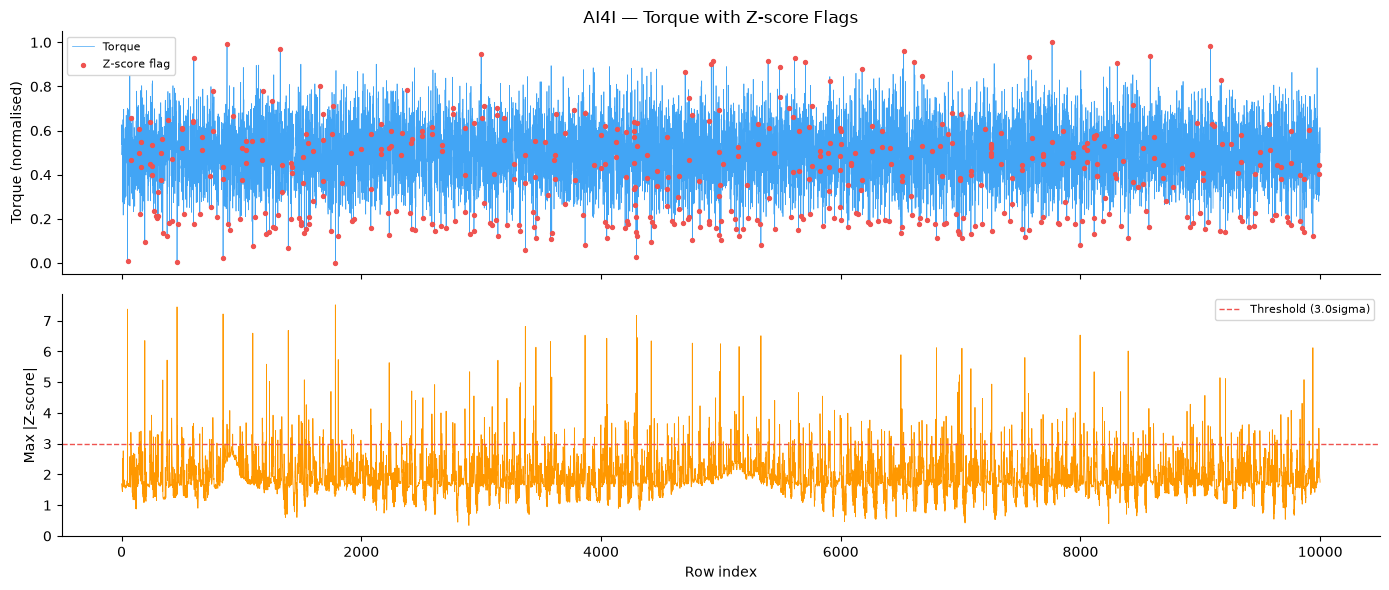

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
idx = ai4i.index
axes[0].plot(idx, ai4i['torque_nm'], color='#42A5F5', linewidth=0.5, label='Torque')
axes[0].scatter(idx[ai4i['zscore_flag']], ai4i['torque_nm'][ai4i['zscore_flag']],
                color='#EF5350', s=8, zorder=5, label='Z-score flag')
axes[0].set_ylabel('Torque (normalised)')
axes[0].legend(fontsize=8)
axes[0].set_title('AI4I — Torque with Z-score Flags')

axes[1].plot(idx, ai4i['zscore_max'], color='#FF9800', linewidth=0.6)
axes[1].axhline(ZSCORE_THRESHOLD, color='#EF5350', linestyle='--', linewidth=1,
                label=f'Threshold ({ZSCORE_THRESHOLD}sigma)')
axes[1].set_ylabel('Max |Z-score|')
axes[1].set_xlabel('Row index')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai4i_zscore.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Detector 2 — Isolation Forest

In [6]:
X = ai4i[SENSOR_COLS].values

clf_if = IsolationForest(
    contamination=IF_CONTAMINATION,
    n_estimators=200,
    random_state=42
)
clf_if.fit(X)

raw_scores = clf_if.score_samples(X)
if_scores  = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
if_flags   = clf_if.predict(X) == -1

ai4i['if_score'] = if_scores
ai4i['if_flag']  = if_flags

n_if = ai4i['if_flag'].sum()
print(f'Isolation Forest flags: {n_if} ({n_if/len(ai4i):.1%})')

Isolation Forest flags: 340 (3.4%)


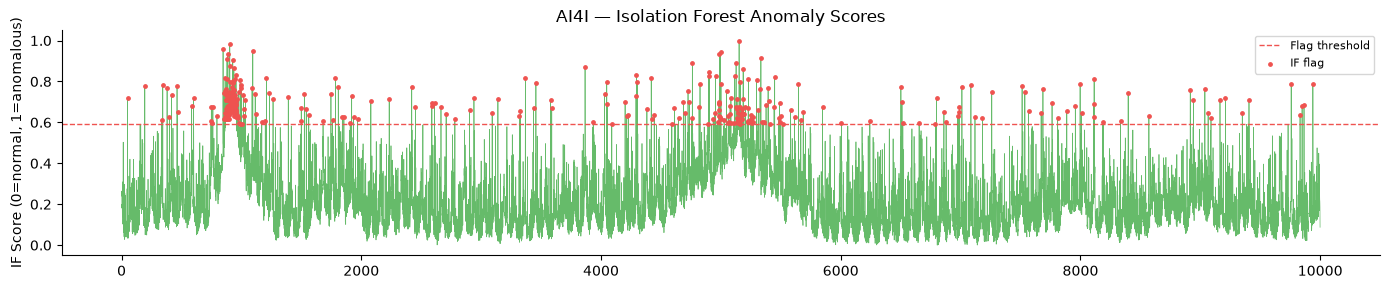

In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(idx, ai4i['if_score'], color='#66BB6A', linewidth=0.5)
threshold_if = ai4i.loc[ai4i['if_flag'], 'if_score'].min()
ax.axhline(threshold_if, color='#EF5350', linestyle='--', linewidth=1, label='Flag threshold')
ax.scatter(idx[ai4i['if_flag']], ai4i['if_score'][ai4i['if_flag']],
           color='#EF5350', s=6, zorder=5, label='IF flag')
ax.set_title('AI4I — Isolation Forest Anomaly Scores')
ax.set_ylabel('IF Score (0=normal, 1=anomalous)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai4i_isolation_forest.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Detector 3 — Autoencoder (PyTorch)

**Architecture:** `5 → 10 → 4 (latent) → 10 → 5`  with BatchNorm after each hidden layer.

**Why this adds value over Z-score + IF:**  
The AE learns the *normal joint distribution* of all 5 sensors together. It flags rows where the combination of sensor values is unusual — even when each individual sensor looks borderline — by measuring how well the model can reconstruct that combination from its compressed latent representation.

**Training:** normal rows only (`machine_failure == 0`).  
**Threshold:** p95 of reconstruction errors on training rows.  
**Per-sensor error:** `(original - reconstructed)^2` per sensor — passed to Stage 3 context payload in place of SHAP.

In [8]:
class Autoencoder(nn.Module):
    """
    Feedforward autoencoder: 5 -> 10 -> 4 -> 10 -> 5.
    Trained on normal rows only. Anomaly score = per-row MSE reconstruction error.
    """
    def __init__(self, n_features: int, latent_dim: int = 4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, n_features * 2),
            nn.ReLU(),
            nn.BatchNorm1d(n_features * 2),
            nn.Linear(n_features * 2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, n_features * 2),
            nn.ReLU(),
            nn.BatchNorm1d(n_features * 2),
            nn.Linear(n_features * 2, n_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def train_autoencoder(
    X_train: np.ndarray,
    n_features: int,
    latent_dim: int = 4,
    n_epochs: int = 150,
    batch_size: int = 256,
    lr: float = 1e-3,
    patience: int = 15,
    device: torch.device = DEVICE
):
    model     = Autoencoder(n_features, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    # 90/10 train/val split
    n_val = int(len(X_train) * 0.1)
    X_t   = torch.FloatTensor(X_train[n_val:]).to(device)
    X_v   = torch.FloatTensor(X_train[:n_val]).to(device)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)

    train_losses, val_losses         = [], []
    best_val, no_improve, best_state = float('inf'), 0, None

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for (batch,) in loader:
            recon = model(batch)
            loss  = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        train_loss = epoch_loss / len(X_t)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), X_v).item()
        model.train()

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f'  Early stop at epoch {epoch+1} — val_loss={best_val:.6f}')
            break
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch {epoch+1:3d} | train={train_loss:.6f} | val={val_loss:.6f}')

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


print('Autoencoder class defined.')

Autoencoder class defined.


In [9]:
X_all    = ai4i[SENSOR_COLS].values.astype(np.float32)
X_normal = ai4i.loc[ai4i[LABEL_COL] == 0, SENSOR_COLS].values.astype(np.float32)

print(f'Training on {len(X_normal)} normal rows '
      f'(excluding {len(X_all)-len(X_normal)} failure rows)')

ae_model, train_losses, val_losses = train_autoencoder(
    X_normal,
    n_features=len(SENSOR_COLS),
    latent_dim=4,
    n_epochs=150,
    batch_size=256,
    lr=1e-3,
    patience=15
)
print('Training complete.')

Training on 9661 normal rows (excluding 339 failure rows)
  Epoch  25 | train=0.002462 | val=0.004393
  Epoch  50 | train=0.001690 | val=0.002104
  Epoch  75 | train=0.001550 | val=0.001658
  Epoch 100 | train=0.001496 | val=0.001458
  Epoch 125 | train=0.001486 | val=0.001415
  Early stop at epoch 148 — val_loss=0.001368
Training complete.


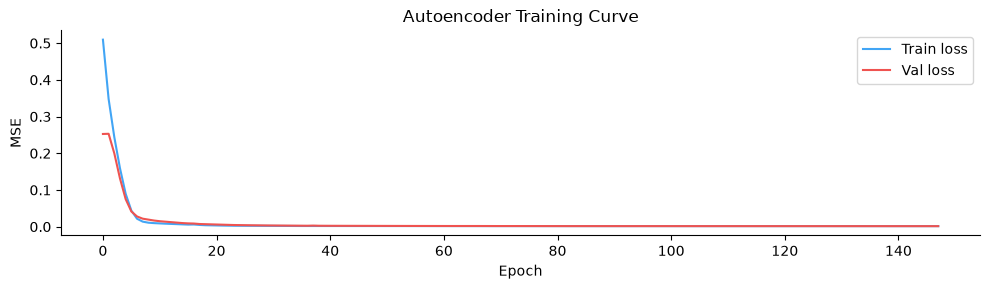

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses, label='Train loss', color='#42A5F5')
ax.plot(val_losses,   label='Val loss',   color='#EF5350')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Autoencoder Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'ae_training_curve.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
# Reconstruction errors on full dataset
ae_model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_all).to(DEVICE)
    X_recon  = ae_model(X_tensor).cpu().numpy()

ae_per_sensor = (X_all - X_recon) ** 2          # shape (N, 5)
ae_errors     = ae_per_sensor.mean(axis=1)       # shape (N,)  — per-row MSE

# Threshold on normal rows only
normal_errors = ae_errors[ai4i[LABEL_COL].values == 0]
ae_threshold  = np.percentile(normal_errors, AE_PERCENTILE)

# Normalise score to [0, 1]  (2x threshold = score 1.0)
ae_scores = np.clip(ae_errors / (ae_threshold * 2), 0, 1)
ae_flags  = ae_errors > ae_threshold

ai4i['ae_error'] = ae_errors
ai4i['ae_score'] = ae_scores
ai4i['ae_flag']  = ae_flags
for i, col in enumerate(SENSOR_COLS):
    ai4i[f'ae_error_{col}'] = ae_per_sensor[:, i]

print(f'AE threshold (p{AE_PERCENTILE} on normal rows): {ae_threshold:.6f}')
print(f'AE flags: {ae_flags.sum()} ({ae_flags.mean():.1%})')

AE threshold (p95 on normal rows): 0.004115
AE flags: 572 (5.7%)


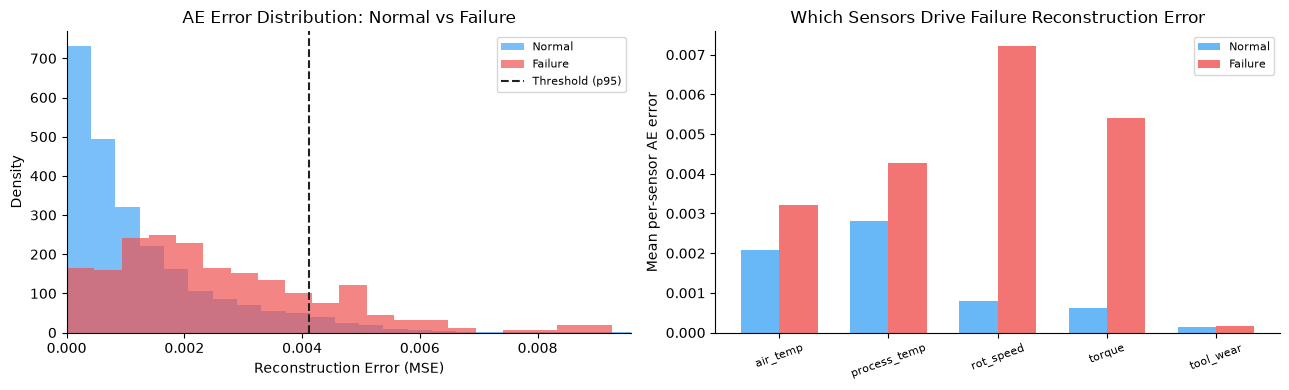

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

normal_err  = ae_errors[ai4i[LABEL_COL].values == 0]
failure_err = ae_errors[ai4i[LABEL_COL].values == 1]

axes[0].hist(normal_err,  bins=60, color='#42A5F5', alpha=0.7, label='Normal',  density=True)
axes[0].hist(failure_err, bins=60, color='#EF5350', alpha=0.7, label='Failure', density=True)
axes[0].axvline(ae_threshold, color='#212121', linestyle='--', linewidth=1.5,
                label=f'Threshold (p{AE_PERCENTILE})')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('AE Error Distribution: Normal vs Failure')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, np.percentile(ae_errors, 99.5))

normal_mask  = ai4i[LABEL_COL].values == 0
failure_mask = ai4i[LABEL_COL].values == 1
sensor_means_normal  = ae_per_sensor[normal_mask].mean(axis=0)
sensor_means_failure = ae_per_sensor[failure_mask].mean(axis=0)

x_pos = np.arange(len(SENSOR_COLS))
width = 0.35
axes[1].bar(x_pos - width/2, sensor_means_normal,  width, label='Normal',  color='#42A5F5', alpha=0.8)
axes[1].bar(x_pos + width/2, sensor_means_failure, width, label='Failure', color='#EF5350', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    [c.replace('_k','').replace('_rpm','').replace('_nm','').replace('_min','')
     for c in SENSOR_COLS], rotation=20, fontsize=8)
axes[1].set_ylabel('Mean per-sensor AE error')
axes[1].set_title('Which Sensors Drive Failure Reconstruction Error')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'ae_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

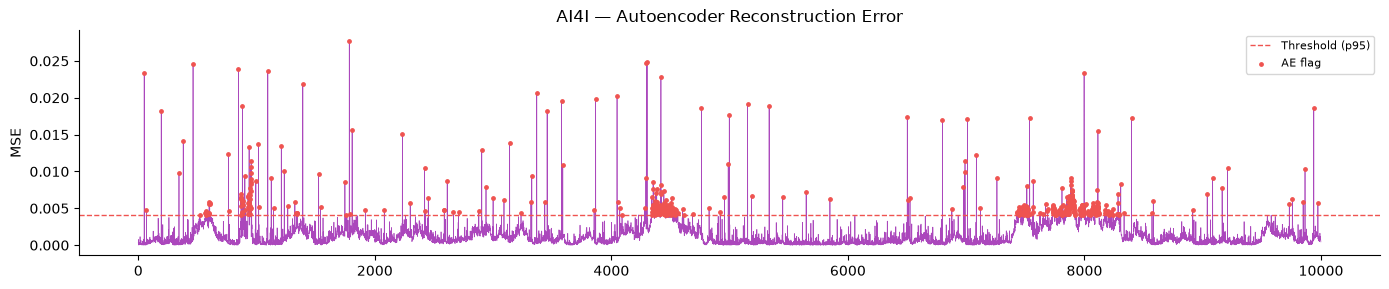

In [13]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(idx, ai4i['ae_error'], color='#AB47BC', linewidth=0.5)
ax.axhline(ae_threshold, color='#EF5350', linestyle='--', linewidth=1,
           label=f'Threshold (p{AE_PERCENTILE})')
ax.scatter(idx[ai4i['ae_flag']], ai4i['ae_error'][ai4i['ae_flag']],
           color='#EF5350', s=6, zorder=5, label='AE flag')
ax.set_title('AI4I — Autoencoder Reconstruction Error')
ax.set_ylabel('MSE')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai4i_autoencoder.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Detector 4 — Domain Rule Flags

Three rule-based detectors derived from the AI4I failure mode definitions, computed in Stage 1 on original-scale values before normalisation:

| Flag | Condition | Targets |
|------|-----------|--------|
| `rule_hdf` | `temp_diff < 8.6 K` AND `rot_speed < 1380 rpm` | Heat Dissipation Failure |
| `rule_twf` | `tool_wear >= 200 min` | Tool Wear Failure |
| `rule_osf` | `tool_wear × torque > 11 000 min·Nm` | Overstrain Failure |

These flags are OR-ed into the combined anomaly decision. They add zero false positives for PWF/RNF and dramatically improve recall for HDF and TWF.

In [14]:
print('=== Rule Flag Coverage (all 4 documented rules) ===')
print(f'{"Rule":<10} {"flags":>6} {"target":>8} {"caught":>7} {"recall":>8} {"precision":>10}  Name')
for rule, ftype, name in [
    ('rule_hdf', 'HDF', 'Heat Dissipation'),
    ('rule_pwf', 'PWF', 'Power Failure'),         # NEW
    ('rule_osf', 'OSF', 'Overstrain'),
    ('rule_twf', 'TWF', 'Tool Wear'),
]:
    flagged = int(ai4i[rule].sum())
    true_n  = int(ai4i[ftype].sum())
    caught  = int((ai4i[rule] & (ai4i[ftype] == 1)).sum())
    recall  = caught / true_n if true_n else 0.0
    prec    = caught / flagged if flagged else 0.0
    print(f'  {rule:<8} {flagged:>6d} {true_n:>8d} {caught:>7d} '
          f'{recall:>7.1%} {prec:>9.1%}  {name}')

print()
print('HDF/PWF/OSF hit ~100% on both metrics because those rules ARE the')
print('definition of those failure types in the dataset paper.')
print('TWF has lower precision: failures happen randomly inside the 200-240 min')
print('window, so the rule alone over-flags. ML confirmation fixes this (see fusion).')


=== Rule Flag Coverage (all 4 documented rules) ===
Rule        flags   target  caught   recall  precision  Name
  rule_hdf    115      115     115  100.0%    100.0%  Heat Dissipation
  rule_pwf     95       95      95  100.0%    100.0%  Power Failure
  rule_osf     98       98      98  100.0%    100.0%  Overstrain
  rule_twf    790       46      43   93.5%      5.4%  Tool Wear

HDF/PWF/OSF hit ~100% on both metrics because those rules ARE the
definition of those failure types in the dataset paper.
TWF has lower precision: failures happen randomly inside the 200-240 min
window, so the rule alone over-flags. ML confirmation fixes this (see fusion).


---
## Score Fusion

In [15]:
TWF_IF_THRESHOLD = 0.30 # IF score must exceed this before TWF rule triggers

def fuse_scores(df, weights=(1/3, 1/3, 1/3), threshold=FUSION_THRESHOLD,
                twf_if_threshold=TWF_IF_THRESHOLD):
    """Improved fusion — three pathways combined with OR.

    Pathway 1 (strict_rules):   HDF, PWF, OSF always flag — ~100% precise
    Pathway 2 (twf_confirmed):  TWF rule + IF score > 0.30 — cuts ~750 false alarms
    Pathway 3 (ml_fusion):      combined ML score > 0.5 — catches what rules miss
    """
    w_z, w_if, w_ae = weights
    zscore_norm = np.clip(df['zscore_max'] / 5.0, 0, 1)
    combined    = w_z * zscore_norm + w_if * df['if_score'] + w_ae * df['ae_score']

    df = df.copy()
    df['zscore_norm']    = zscore_norm
    df['combined_score'] = combined

    strict_rules  = df['rule_hdf'] | df['rule_pwf'] | df['rule_osf']
    twf_confirmed = df['rule_twf'] & (df['if_score'] > twf_if_threshold)
    ml_fusion     = combined > 0.70

    df['anomaly'] = strict_rules | twf_confirmed | ml_fusion

    n_agree = (df['zscore_flag'].astype(int) +
               df['if_flag'].astype(int) +
               df['ae_flag'].astype(int))
    df['agreement'] = n_agree.map(
        {0: 'none', 1: 'one_only', 2: 'two_of_three', 3: 'all_three'})

    df['rule_count'] = (df['rule_hdf'].astype(int) + df['rule_pwf'].astype(int) +
                        df['rule_osf'].astype(int) + df['rule_twf'].astype(int))
    return df

ai4i = fuse_scores(ai4i)

print('=== Improved Fusion Results ===')
strict_rules  = ai4i['rule_hdf'] | ai4i['rule_pwf'] | ai4i['rule_osf']
twf_confirmed = ai4i['rule_twf'] & (ai4i['if_score'] > TWF_IF_THRESHOLD)
ml_only = (ai4i['combined_score'] > 0.70) & ~(strict_rules | twf_confirmed)

print(f'Pathway 1 — strict rules (HDF|PWF|OSF):  {int(strict_rules.sum()):>5d} flags')
print(f'Pathway 2 — TWF confirmed by ML:          {int(twf_confirmed.sum()):>5d} flags')
print(f'Pathway 3 — ML-only safety net:           {int(ml_only.sum()):>5d} flags')
print(f'Total anomaly flags:                      {int(ai4i["anomaly"].sum()):>5d} ({ai4i["anomaly"].mean():.1%})')
print()
print('Detector agreement:')
print(ai4i['agreement'].value_counts().to_string())


=== Improved Fusion Results ===
Pathway 1 — strict rules (HDF|PWF|OSF):    287 flags
Pathway 2 — TWF confirmed by ML:            354 flags
Pathway 3 — ML-only safety net:              60 flags
Total anomaly flags:                        638 (6.4%)

Detector agreement:
agreement
none            8903
one_only         873
two_of_three     123
all_three        101


In [16]:
# ── Threshold sweep — find the best TWF + ML combination ─────────────────
from sklearn.metrics import precision_recall_fscore_support

y_true = ai4i['label_348'].values

print(f"{'TWF_IF':>8} {'ML_thr':>8} {'Flags':>7} {'TWF':>6} {'Prec':>7} {'Rec':>7} {'F1':>7}  {'Eff.Rec':>9}")
print("-" * 75)

best_f1, best_cfg = 0, {}

for twf_t in [0.10, 0.20, 0.30, 0.40, 0.50]:
    for ml_t in [0.50, 0.55, 0.60, 0.65, 0.70]:

        strict  = ai4i['rule_hdf'] | ai4i['rule_pwf'] | ai4i['rule_osf']
        twf_c   = ai4i['rule_twf'] & (ai4i['if_score'] > twf_t)
        ml_c    = ai4i['combined_score'] > ml_t
        pred    = (strict | twf_c | ml_c).astype(int).values

        p, r, f1, _ = precision_recall_fscore_support(
            y_true, pred, average='binary', zero_division=0)

        twf_caught = int((ai4i['TWF']==1 & (strict|twf_c|ml_c)).sum())
        flags      = int(pred.sum())

        non_rnf_caught = int(((ai4i['label_348']==1) &
                               (strict|twf_c|ml_c).astype(bool) &
                               (ai4i['RNF']==0)).sum())
        eff_rec = non_rnf_caught / 329

        marker = " ◄ BEST" if f1 > best_f1 else ""
        if f1 > best_f1:
            best_f1  = f1
            best_cfg = {'twf': twf_t, 'ml': ml_t, 'f1': f1,
                        'prec': p, 'rec': r, 'flags': flags, 'eff_rec': eff_rec}

        print(f"  {twf_t:>6.2f}   {ml_t:>6.2f}  {flags:>7d} {twf_caught:>4d}/46"
              f"  {p:>6.3f}  {r:>6.3f}  {f1:>6.3f}  {eff_rec:>8.1%}{marker}")

print()
print("=" * 75)
print(f"BEST COMBINATION:")
print(f"  TWF_IF_THRESHOLD = {best_cfg['twf']}")
print(f"  ML threshold     = {best_cfg['ml']}")
print(f"  F1               = {best_cfg['f1']:.3f}")
print(f"  Precision        = {best_cfg['prec']:.3f}")
print(f"  Recall           = {best_cfg['rec']:.3f}")
print(f"  Total flags      = {best_cfg['flags']}")
print(f"  Effective recall = {best_cfg['eff_rec']:.1%}")

  TWF_IF   ML_thr   Flags    TWF    Prec     Rec      F1    Eff.Rec
---------------------------------------------------------------------------
    0.10     0.50     1214 8828/46   0.271   0.945   0.421     99.4% ◄ BEST
    0.10     0.55     1145 8897/46   0.287   0.945   0.441     99.4% ◄ BEST
    0.10     0.60     1105 8937/46   0.298   0.945   0.453     99.4% ◄ BEST
    0.10     0.65     1074 8968/46   0.306   0.945   0.463     99.4% ◄ BEST
    0.10     0.70     1054 8988/46   0.312   0.945   0.469     99.4% ◄ BEST
    0.20     0.50     1035 8989/46   0.309   0.920   0.463     97.0%
    0.20     0.55      966 9058/46   0.331   0.920   0.487     97.0% ◄ BEST
    0.20     0.60      926 9098/46   0.346   0.920   0.502     97.0% ◄ BEST
    0.20     0.65      895 9129/46   0.358   0.920   0.515     97.0% ◄ BEST
    0.20     0.70      875 9149/46   0.366   0.920   0.523     97.0% ◄ BEST
    0.30     0.50      798 9212/46   0.392   0.899   0.546     94.8% ◄ BEST
    0.30     0.55      729 

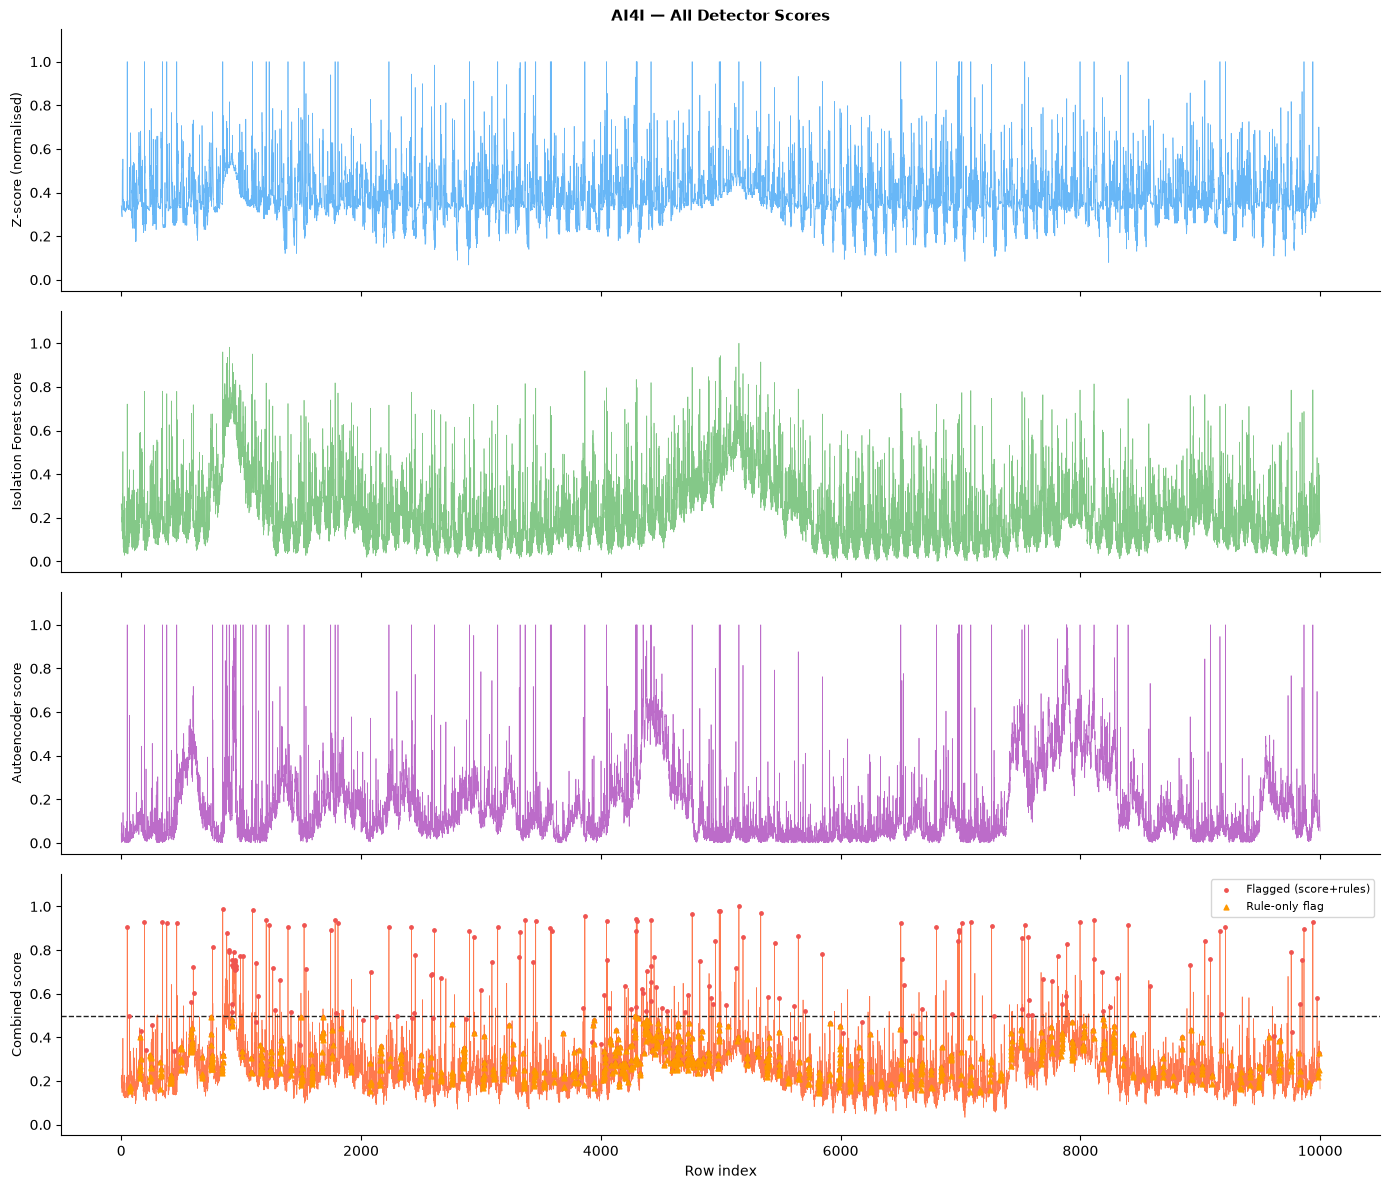

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
series = [
    ('zscore_norm',    'Z-score (normalised)',    '#42A5F5'),
    ('if_score',       'Isolation Forest score',  '#66BB6A'),
    ('ae_score',       'Autoencoder score',        '#AB47BC'),
    ('combined_score', 'Combined score',           '#FF5722'),
]
for ax, (col, label, color) in zip(axes, series):
    ax.plot(idx, ai4i[col], color=color, linewidth=0.5, alpha=0.8)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    if col == 'combined_score':
        ax.axhline(FUSION_THRESHOLD, color='#212121', linestyle='--', linewidth=1)
        ax.scatter(idx[ai4i['anomaly']], ai4i.loc[ai4i['anomaly'], col],
                   color='#EF5350', s=6, zorder=5, label='Flagged (score+rules)')
        # Highlight rule-only flags
        rule_only = (ai4i['rule_hdf']|ai4i['rule_twf']|ai4i['rule_osf']) & \
                    ~(ai4i['combined_score'] > FUSION_THRESHOLD)
        ax.scatter(idx[rule_only], ai4i.loc[rule_only, col],
                   color='#FF9800', s=12, zorder=6, marker='^', label='Rule-only flag')
        ax.legend(fontsize=8)
axes[0].set_title('AI4I — All Detector Scores', fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Row index')
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai4i_detector_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


---
## Evaluation Against Ground Truth

In [18]:
from sklearn.metrics import precision_recall_fscore_support

print('=== Per-Detector Performance (Precision / Recall / F1) ===')
print(f'{"Detector":<22} | {"vs 339 (machine_failure)":<28} | {"vs 348 (any flag)"}')
print(f'{"":22} | {"Prec    Rec    F1":<28} | Prec    Rec    F1')
print('-' * 82)

for name, col in [('Z-score',         'zscore_flag'),
                  ('Isolation Forest', 'if_flag'),
                  ('Autoencoder',      'ae_flag'),
                  ('Combined (final)', 'anomaly')]:
    y_pred = ai4i[col].astype(int).values
    row_parts = []
    for label_col in ['label_339', 'label_348']:
        y_true = ai4i[label_col].values
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', zero_division=0)
        row_parts.append(f'{p:.3f}   {r:.3f}   {f1:.3f}')
    print(f'{name:<22} | {row_parts[0]:<28} | {row_parts[1]}')

print()
print('=== Per-Failure-Type Detection (Combined detector, ground truth = 348) ===')
print(f'{"Type":<6} {"In data":>8} {"Caught":>7} {"Rate":>6}  Notes')
notes = {
    'HDF': 'physics rule exact — should always hit 100%',
    'PWF': 'physics rule exact — NEW, was missing before',
    'OSF': 'physics rule exact — now type-aware',
    'TWF': 'wear window + IF confirmation (tradeoff: fewer false alarms)',
    'RNF': 'random by design — uncatchable, exclude from headline recall',
}
for ftype in ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']:
    mask   = ai4i[ftype] == 1
    caught = int(ai4i.loc[mask, 'anomaly'].sum())
    total  = int(mask.sum())
    rate   = caught / total if total else 0.0
    print(f'  {ftype:<4} {total:>8d} {caught:>7d} {rate:>5.0%}  {notes[ftype]}')

non_rnf_total  = int((ai4i['label_348'] == 1).sum() - ai4i['RNF'].sum())
non_rnf_caught = int(((ai4i['label_348'] == 1) & ai4i['anomaly'] & (ai4i['RNF'] == 0)).sum())
print()
print(f'Effective recall (excluding uncatchable RNF): {non_rnf_caught}/{non_rnf_total} '
      f'= {non_rnf_caught/non_rnf_total:.1%}')


=== Per-Detector Performance (Precision / Recall / F1) ===
Detector               | vs 339 (machine_failure)     | vs 348 (any flag)
                       | Prec    Rec    F1            | Prec    Rec    F1
----------------------------------------------------------------------------------
Z-score                | 0.110   0.165   0.132        | 0.112   0.164   0.133
Isolation Forest       | 0.141   0.142   0.141        | 0.141   0.138   0.140
Autoencoder            | 0.156   0.263   0.195        | 0.159   0.261   0.198
Combined (final)       | 0.491   0.923   0.641        | 0.491   0.899   0.635

=== Per-Failure-Type Detection (Combined detector, ground truth = 348) ===
Type    In data  Caught   Rate  Notes
  HDF       115     115  100%  physics rule exact — should always hit 100%
  PWF        95      95  100%  physics rule exact — NEW, was missing before
  OSF        98      98  100%  physics rule exact — now type-aware
  TWF        46      28   61%  wear window + IF confirmation (trad

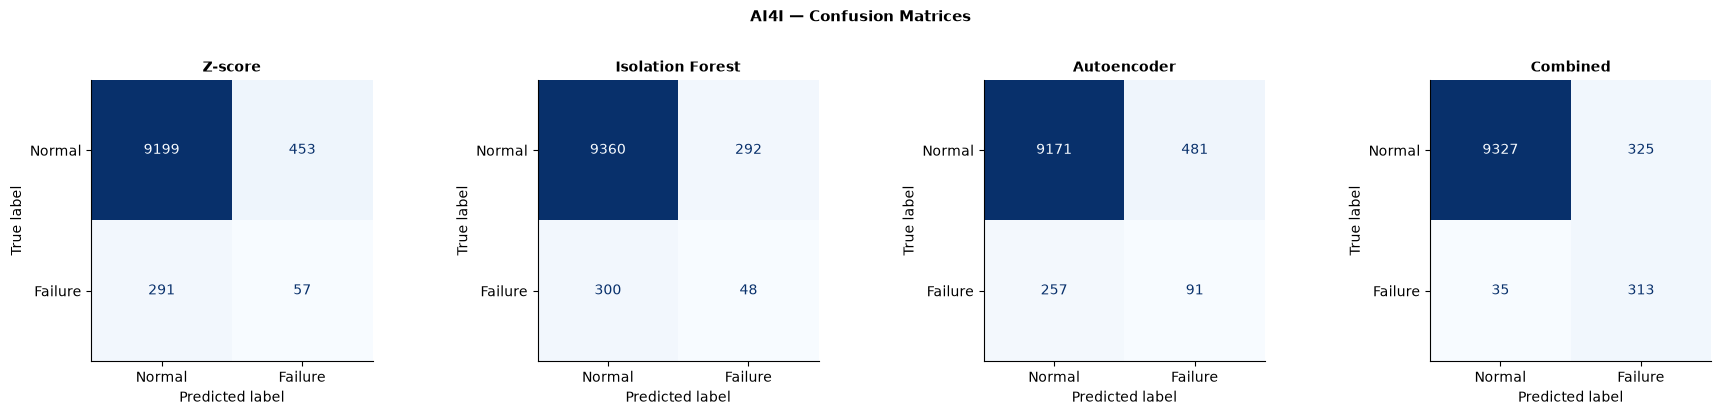

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, col) in zip(axes, [('Z-score',         'zscore_flag'),
                                   ('Isolation Forest','if_flag'),
                                   ('Autoencoder',     'ae_flag'),
                                   ('Combined',        'anomaly')]):
    cm   = confusion_matrix(y_true, ai4i[col].astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Failure'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.suptitle('AI4I — Confusion Matrices', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai4i_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
print('=== Detection Rate per Failure Type (Combined) ===')
for ftype, name in [('HDF','Heat Dissipation'), ('PWF','Power'),
                    ('OSF','Overstrain'),        ('TWF','Tool Wear'),
                    ('RNF','Random')]:
    mask     = ai4i[ftype] == 1
    detected = ai4i.loc[mask, 'anomaly'].sum()
    total    = mask.sum()
    bar      = 'X' * int(detected / total * 20) if total > 0 else ''
    print(f'  {name:<20} {detected:3d}/{total:3d}  ({detected/total:.0%})  {bar}')

=== Detection Rate per Failure Type (Combined) ===
  Heat Dissipation     115/115  (100%)  XXXXXXXXXXXXXXXXXXXX
  Power                 95/ 95  (100%)  XXXXXXXXXXXXXXXXXXXX
  Overstrain            98/ 98  (100%)  XXXXXXXXXXXXXXXXXXXX
  Tool Wear             28/ 46  (61%)  XXXXXXXXXXXX
  Random                 1/ 19  (5%)  X


---
## Export — Anomaly Records for Stage 3

In [21]:
def build_anomaly_records(df, sensor_cols, ranges, window=SENSOR_WINDOW):
    records = []
    for row_idx in df.index[df['anomaly']].tolist():
        row = df.iloc[row_idx]

        # Worst sensor by global Z-score magnitude
        zs    = {c: abs(row.get(f'{c}_zscore_global', 0)) for c in sensor_cols}
        worst = max(zs, key=zs.get)

        # Local +-window readings for context
        start    = max(0, row_idx - window)
        end      = min(len(df), row_idx + window + 1)
        win_vals = df[worst].iloc[start:end].round(4).tolist()

        record = {
            'dataset':       'ai4i',
            'row_idx':       int(row_idx),
            'worst_sensor':  worst,
            'flagged_value': round(float(row[worst]), 4),

            # Local context
            'window':        win_vals,
            'window_median': round(float(np.median(win_vals)), 4),
            'window_std':    round(float(np.std(win_vals)), 4),

            # Global context
            'global_mean':   ranges[worst]['mean'],
            'global_std':    ranges[worst]['std'],
            'global_p5':     round(float(df[worst].quantile(0.05)), 4),
            'global_p95':    round(float(df[worst].quantile(0.95)), 4),

            # Detector outputs
            'zscore_max':          round(float(row['zscore_max']), 3),
            'zscore_flag':         bool(row['zscore_flag']),
            'if_score':            round(float(row['if_score']), 3),
            'if_flag':             bool(row['if_flag']),
            'ae_error_total':      round(float(row['ae_error']), 6),
            'ae_error_per_sensor': {
                c: round(float(row[f'ae_error_{c}']), 6) for c in sensor_cols
            },
            'ae_flag':             bool(row['ae_flag']),

            # Domain rule flags
            'rule_hdf':            bool(row['rule_hdf']),
            'rule_pwf':            bool(row.get('rule_pwf', False)),
            'rule_twf':            bool(row['rule_twf']),
            'rule_osf':            bool(row['rule_osf']),

            'combined_score':      round(float(row['combined_score']), 3),
            'agreement':           row['agreement'],

            # Ground truth
            'true_label':   int(row['machine_failure']),
            'failure_type': row.get('failure_type', None)
        }
        records.append(record)
    return records


records = build_anomaly_records(ai4i, SENSOR_COLS, ai4i_ranges)
with open(DATA_DIR / 'ai4i_anomaly_records.json', 'w') as f:
    json.dump(records, f, indent=2)

from collections import Counter
print(f'Exported {len(records)} anomaly records -> ai4i_anomaly_records.json')
print(f'Agreement breakdown: {dict(Counter(r["agreement"] for r in records))}')
print()
print('Sample record keys:', list(records[0].keys()))


Exported 638 anomaly records -> ai4i_anomaly_records.json
Agreement breakdown: {'all_three': 89, 'one_only': 85, 'none': 426, 'two_of_three': 38}

Sample record keys: ['dataset', 'row_idx', 'worst_sensor', 'flagged_value', 'window', 'window_median', 'window_std', 'global_mean', 'global_std', 'global_p5', 'global_p95', 'zscore_max', 'zscore_flag', 'if_score', 'if_flag', 'ae_error_total', 'ae_error_per_sensor', 'ae_flag', 'rule_hdf', 'rule_pwf', 'rule_twf', 'rule_osf', 'combined_score', 'agreement', 'true_label', 'failure_type']


In [22]:
# Save trained model for Stage 3 reuse
torch.save(ae_model.state_dict(), DATA_DIR / 'ae_ai4i.pt')
print('Model saved -> data/ae_ai4i.pt')
print()
print('=== Stage 2 Complete ===')
print(f'  Anomaly records : {len(records)}')
print(f'  True positives  : {sum(1 for r in records if r["true_label"]==1)}')
print(f'  False positives : {sum(1 for r in records if r["true_label"]==0)}')
print()
print('Next: Stage 3+4 -> xai.ipynb')

Model saved -> data/ae_ai4i.pt

=== Stage 2 Complete ===
  Anomaly records : 638
  True positives  : 313
  False positives : 325

Next: Stage 3+4 -> xai.ipynb
